# Data Collection (ml.m5.12xlarge)

In [1]:
import boto3
import pandas as pd
import numpy as np
import os
import pickle
from pandas.api.types import is_numeric_dtype
from pprint import pprint
import seaborn as sns
import matplotlib.pyplot as plt

### Functions

In [2]:
def create_target(bitTarget24Months, RunningNetLoss):
    if (bitTarget24Months == 1) and (RunningNetLoss > 0):
        return 1
    else:
        return 0

In [3]:
# plot target
def plot_target(ser_target):
    # get min/max
    flt_min = ser_target.min()
    flt_max = ser_target.max()
    # show distribution
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Distribution of Target (N = {len(ser_target)}; Min = {flt_min:0.2f}; Max = {flt_max:0.2f})')
    sns.distplot(list(ser_target), ax=ax)
    plt.show()

### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# date column
str_datecol = 'applicationdate__app'
# output
str_dirname_output = './output'
# n rows (for testing)
int_n_rows = None
#int_n_rows = 1000
# bucket
cls_bucket = boto3.resource('s3').Bucket(str_project)

Project: 20231010-gen-xii


### Create output directory

In [5]:
# create dir
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    print(f'Directory {str_dirname_output} already exists')

Directory ./output already exists


### Import data for approval/decline model

In [6]:
%%time

str_filename = 'df_raw.gzip'
str_uri = f's3://{str_project}/01_ad/01_data_prep/01_data_collection/output/{str_filename}'
df = pd.read_parquet(str_uri)

# show
df

CPU times: user 2min 26s, sys: 4min 40s, total: 7min 7s
Wall time: 17.4 s


,bitdebtor__base,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,dtmfunded__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,...,us934d__tu,us934s__tu,us935b__tu,us935c__tu,us935d__tu,us935s__tu,score_bankcard__tu,score_cvpropensity__tu,finscore__tu,intscore__ln
0,0.0,20181103.0,20181103.0,NaN,NaN,201810.0,73140.0,2018-11-03,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,20181103.0,NaN,20181103.0,NaN,201810.0,72817.0,2018-11-03,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,20181103.0,NaN,20181103.0,NaN,201810.0,74494.0,2018-11-03,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,20181030.0,NaN,20181030.0,NaN,201810.0,61357.0,2018-10-30,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,20181031.0,20181031.0,NaN,NaN,201810.0,61417.0,2018-10-31,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,NaN,555.0,588.0
2100694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,451.0,571.0,574.0
2100695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,447.0,616.0,568.0
2100696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,501.0,648.0,595.0


In [7]:
%%time

# drop features that are in the target data
list_cols = [
    'target', # --> bitdefault__app
    'applicationdate__app', # --> dtmstampcreation__app
    'fltapprovedpayment__app', # --> payment__app
    'inttype__app', # --> intopenbktype
    'fltapprovedpricewholesale__app', # --> bookvalue__app
    'fltamountfinanced__app', # --> amtfinanced__app
    #'bigaccountid__app',
    'bigdebtorid__app',
    'bigaccountid',
    'bigdebtorid',
    'bitdebtor__base',
    'bitdebtor__tu',
    'bitdebtor__app',
    'dtmfunded__base',
    'dtmfunded__tu',
    'dtmfunded__app',
    'fltamountfinanced__app',
    'intterm__app',
    'vehicleyear__app',
    'bitnew__app',
    'vehiclemake__app',
    'fltdowncash__app',
    'fltapproveddowntotal__app',
    'pti__app',
    'bitservicecontract__app',
    'fltadvance__app',
]
df.drop(list_cols, axis=1, inplace=True)

# show
df

CPU times: user 6.39 s, sys: 12.7 s, total: 19.1 s
Wall time: 15 s


,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,us934d__tu,us934s__tu,us935b__tu,us935c__tu,us935d__tu,us935s__tu,score_bankcard__tu,score_cvpropensity__tu,finscore__tu,intscore__ln
0,20181103.0,20181103.0,NaN,201810.0,73140.0,2018-11-03,0.0,AU,2018-11-12,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20181103.0,NaN,20181103.0,201810.0,72817.0,2018-11-03,0.0,AU,2018-11-10,17188.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20181103.0,NaN,20181103.0,201810.0,74494.0,2018-11-03,0.0,AU,2018-11-06,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20181030.0,NaN,20181030.0,201810.0,61357.0,2018-10-30,0.0,AU,2018-11-15,13065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20181031.0,20181031.0,NaN,201810.0,61417.0,2018-10-31,0.0,AU,2018-10-31,20150.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100693,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,NaN,555.0,588.0
2100694,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,451.0,571.0,574.0
2100695,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,447.0,616.0,568.0
2100696,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,501.0,648.0,595.0


### Subset to funded accounts only

In [8]:
str_col = 'bitfunded__app'
ser_val_counts = df[str_col].value_counts()
# show
ser_val_counts

bitfunded__app
0.0    1770866
1.0     186089
Name: count, dtype: int64

In [9]:
# propna
flt_propna = df[str_col].isnull().mean()
print(f'Proportion NaN in {str_col}: {flt_propna:0.3f}')

Proportion NaN in bitfunded__app: 0.068


In [10]:
%%time

df = df[df[str_col] == 1]

# show
df

CPU times: user 3.14 s, sys: 3.53 s, total: 6.67 s
Wall time: 3.79 s


,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,us934d__tu,us934s__tu,us935b__tu,us935c__tu,us935d__tu,us935s__tu,score_bankcard__tu,score_cvpropensity__tu,finscore__tu,intscore__ln
10,20181107.0,20181107.0,NaN,201810.0,95513.0,2018-11-07,1.0,AU,2018-11-06,17496.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,20181121.0,20181121.0,NaN,201810.0,109430.0,2018-11-21,1.0,AU,2018-11-21,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,20181117.0,20181227.0,NaN,201810.0,108781.0,2018-11-17,1.0,AU,2018-11-23,15069.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,20181004.0,20181004.0,NaN,201810.0,2090.0,2018-10-04,1.0,AU,2018-10-31,12333.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,20181020.0,20181020.0,NaN,201810.0,53961.0,2018-10-20,1.0,AU,2018-10-25,2331.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100299,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,5.0,604.0,668.0,606.0
2100369,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,0.0,571.0,570.0,571.0
2100427,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,0.0,530.0,555.0,556.0
2100538,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,NaN,482.0,559.0


### Get bigaccountid__app from uniqueid

In [11]:
list_cols = [
    'uniqueid', 
    'bigaccountid__app',
]
df_tmp = df[list_cols].copy()
df_tmp

,uniqueid,bigaccountid__app
10,3.974444e+14,NaN
19,3.999583e+14,NaN
25,3.993828e+14,NaN
34,3.914615e+14,NaN
47,3.942791e+14,NaN
...,...,...
2100299,3.948725e+14,3948724.0
2100369,3.950362e+14,3950361.0
2100427,3.953108e+14,3953107.0
2100538,3.957142e+14,3957141.0


In [12]:
# create tmp col
df['col_tmp'] = df['uniqueid'].astype(str).str.slice(0,7).astype(int)
# show
list_cols = [
    'col_tmp',
]
df_tmp = df[list_cols].copy()
df_tmp

/tmp/ipykernel_55253/485546842.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['col_tmp'] = df['uniqueid'].astype(str).str.slice(0,7).astype(int)


,col_tmp
10,3974443
19,3999582
25,3993827
34,3914614
47,3942790
...,...
2100299,3948724
2100369,3950361
2100427,3953107
2100538,3957141


In [13]:
# fillna
df['bigaccountid__app'] = df['bigaccountid__app'].fillna(df['col_tmp']).astype(int)
df.drop('col_tmp', axis=1, inplace=True)
# show
list_cols = [
    'uniqueid', 
    'bigaccountid__app',
]
df_tmp = df[list_cols].copy()
df_tmp

/tmp/ipykernel_55253/202723563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bigaccountid__app'] = df['bigaccountid__app'].fillna(df['col_tmp']).astype(int)
/tmp/ipykernel_55253/202723563.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('col_tmp', axis=1, inplace=True)


,uniqueid,bigaccountid__app
10,3.974444e+14,3974443
19,3.999583e+14,3999582
25,3.993828e+14,3993827
34,3.914615e+14,3914614
47,3.942791e+14,3942790
...,...,...
2100299,3.948725e+14,3948724
2100369,3.950362e+14,3950361
2100427,3.953108e+14,3953107
2100538,3.957142e+14,3957141


### Import TSP features

In [14]:
%%time

# import target
str_filename = 'df_target_pd.csv'
str_uri = f's3://{str_project}/ad_hoc/target_pd/{str_filename}'
df_tmp = pd.read_csv(str_uri)

# drop target
list_cols = [
    'bitdefault__app',
    'bigaccountid__app',
]
df_tmp.drop(list_cols, axis=1, inplace=True)

# convert to datetime
df_tmp['dtmstampcreation__app'] = pd.to_datetime(df_tmp['dtmstampcreation__app'])
df_tmp['dealerstampcreation__app'] = pd.to_datetime(df_tmp['dealerstampcreation__app'])

# rename
dict_rename = {
#     'bitdefault__app': 'target',
    'dtmstampcreation__app': 'applicationdate__app',
#     'payment__app': 'fltapprovedpayment__app',
#     'intopenbktype__app': 'inttype__app',
#     'bookvalue__app': 'fltapprovedpricewholesale__app',
#     'amtfinanced__app': 'fltamountfinanced__app',
}
df_tmp.rename(columns=dict_rename, inplace=True)

# show
df_tmp

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:273: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
<timed exec>:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.


CPU times: user 1.08 s, sys: 117 ms, total: 1.2 s
Wall time: 3.99 s


,uniqueid__app,bigdebtorid__app,bitdebtor__app,applicationdate__app,dtmfunded__app,monthonbooks__app,runningnetloss__app,amtfinanced__app,intopenbktype__app,intterm__app,...,fltdowncash__app,fltapproveddowntotal__app,payment__app,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app
0,133767817566601,1756660,1,2013-10-01 10:24:32.527,2013-10-21 00:00:00.000,72,0.0,12152.00,7.0,60,...,1500.0,1500.0,314.19,0.222419,0.049405,0,0.940365,auto,0,2006-04-02 17:40:05.000
1,133774717567541,1756754,1,2013-10-01 11:01:41.130,2013-10-11 00:00:00.000,72,0.0,15831.73,NaN,66,...,500.0,500.0,364.53,0.510817,0.115263,0,1.048115,suv,1,2010-09-28 11:06:49.813
2,133778017567981,1756798,1,2013-10-01 11:25:23.807,2013-10-04 00:00:00.000,72,0.0,17335.26,NaN,72,...,1040.0,1040.0,394.88,0.396283,0.121472,0,1.121117,auto,0,2011-08-31 09:02:45.850
3,133780717568341,1756834,1,2013-10-01 11:41:51.333,2013-10-14 00:00:00.000,72,0.0,15422.00,NaN,66,...,500.0,500.0,413.68,0.505432,0.158861,0,1.094022,auto,0,2012-01-26 09:55:34.480
4,133781117568381,1756838,1,2013-10-01 11:44:35.337,2013-10-10 00:00:00.000,72,0.0,18570.70,7.0,72,...,1000.0,1000.0,450.11,0.482546,0.082613,1,1.146076,auto,1,2006-01-04 10:58:20.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196834,481138661285821,6128583,0,2019-12-31 07:56:11.937,2020-02-18 00:00:00.000,44,0.0,22631.56,13.0,66,...,1000.0,1000.0,527.34,0.371485,0.053058,0,1.058707,suv,0,2018-11-21 11:01:46.307
196835,481150161287221,6128723,0,2019-12-31 09:10:49.117,2020-01-08 00:00:00.000,45,0.0,20024.75,13.0,72,...,500.0,500.0,454.07,0.300602,0.063171,1,1.234773,suv,0,2009-06-11 17:08:59.937
196836,481157161288091,6128810,0,2019-12-31 09:43:20.773,2020-01-31 00:00:00.000,45,0.0,15796.96,13.0,72,...,0.0,0.0,344.86,0.280712,0.100332,1,1.221195,auto,1,2019-08-09 13:53:46.860
196837,481178461290801,6129081,0,2019-12-31 11:14:46.693,2020-01-09 00:00:00.000,45,0.0,21666.29,7.0,72,...,1000.0,1000.0,443.03,0.271795,0.068680,0,1.106953,auto,1,2015-01-21 14:44:01.150


### Join

In [15]:
df = pd.merge(
    left=df,
    right=df_tmp,
    left_on='uniqueid',
    right_on='uniqueid__app',
    how='inner',
)
# show
df

,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,fltdowncash__app,fltapproveddowntotal__app,payment__app,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app
0,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,755.01,755.01,258.37,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657
1,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,755.01,755.01,258.37,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657
2,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,4750.00,-96.00,735.23,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530
3,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,4750.00,-96.00,735.23,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530
4,20181030.0,20181030.0,NaN,201810.0,65604.0,2018-10-30,1.0,AU,2018-10-30,0.0,...,0.00,1000.00,429.94,0.191788,0.071203,0,1.082675,truck,1,2011-05-20 14:53:37.283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.00,1150.00,505.00,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440
186171,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.00,1150.00,505.00,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440
186172,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,500.00,500.00,472.10,0.352323,0.121456,0,1.149966,auto,0,2013-02-21 14:58:51.357
186173,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,12000.00,16751.82,776.23,0.299975,0.062550,0,0.741723,suv,0,2011-09-20 11:51:00.783


### Import targets

In [16]:
list_cols = [
    'bigAccountId',
    'RunningNetLoss',
    'bitTarget24Months',
]
str_filename = 'df_targets.csv'
str_uri = f's3://{str_project}/ad_hoc/03_target_creation/{str_filename}'
df_tmp = pd.read_csv(str_uri, usecols=list_cols)
dict_rename = {
    'bigAccountId': 'bigaccountid__app',
}
df_tmp.rename(columns=dict_rename, inplace=True)
df_tmp

,bigaccountid__app,RunningNetLoss,bitTarget24Months
0,3,0.0,0
1,6,0.0,0
2,11,0.0,0
3,39,0.0,0
4,58,0.0,0
...,...,...,...
352760,6039439,0.0,0
352761,6039440,0.0,0
352762,6039725,0.0,0
352763,6040798,18769.1,1


### Join

In [17]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigaccountid__app',
    how='left',
)
df

,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,payment__app,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,RunningNetLoss,bitTarget24Months
0,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,258.37,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657,0.0,0
1,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,258.37,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657,0.0,0
2,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,735.23,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530,0.0,0
3,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,735.23,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530,0.0,0
4,20181030.0,20181030.0,NaN,201810.0,65604.0,2018-10-30,1.0,AU,2018-10-30,0.0,...,429.94,0.191788,0.071203,0,1.082675,truck,1,2011-05-20 14:53:37.283,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,505.00,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440,0.0,0
186171,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,505.00,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440,0.0,0
186172,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,472.10,0.352323,0.121456,0,1.149966,auto,0,2013-02-21 14:58:51.357,0.0,0
186173,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,776.23,0.299975,0.062550,0,0.741723,suv,0,2011-09-20 11:51:00.783,0.0,0


### Create binary target

In [18]:
df['target'] = df.apply(
    lambda x: create_target(
        bitTarget24Months=x['bitTarget24Months'], 
        RunningNetLoss=x['RunningNetLoss'],
    ),
    axis=1,
)
df

,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,RunningNetLoss,bitTarget24Months,target
0,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657,0.0,0,0
1,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657,0.0,0,0
2,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530,0.0,0,0
3,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530,0.0,0,0
4,20181030.0,20181030.0,NaN,201810.0,65604.0,2018-10-30,1.0,AU,2018-10-30,0.0,...,0.191788,0.071203,0,1.082675,truck,1,2011-05-20 14:53:37.283,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440,0.0,0,0
186171,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440,0.0,0,0
186172,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.352323,0.121456,0,1.149966,auto,0,2013-02-21 14:58:51.357,0.0,0,0
186173,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.299975,0.062550,0,0.741723,suv,0,2011-09-20 11:51:00.783,0.0,0,0


### Subset

In [19]:
# went 60+DPD in 24 mo
df = df[df['target'] == 1].copy()
df

,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,RunningNetLoss,bitTarget24Months,target
11,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,1
12,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,1
19,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,1
20,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,1
21,20181017.0,20181017.0,NaN,201810.0,34747.0,2018-10-17,1.0,AU,2018-10-17,17428.0,...,0.380302,0.149874,0,1.253794,auto,0,2003-07-08 14:32:29.097,9584.90,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186164,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.203666,0.100599,0,1.210315,truck,0,2013-04-02 15:33:30.193,28198.75,1,1
186165,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.358319,0.113501,1,1.176435,auto,1,2014-09-09 16:07:25.123,13195.01,1,1
186166,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.334282,0.121807,0,1.150000,auto,1,2012-11-05 16:48:22.563,7251.90,1,1
186168,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.419962,0.109622,0,1.249284,auto,0,2011-06-21 16:14:20.870,11811.67,1,1


In [20]:
# positive net charge off
df = df[df['RunningNetLoss'] > 0].copy()
df

,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,RunningNetLoss,bitTarget24Months,target
11,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,1
12,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,1
19,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,1
20,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,1
21,20181017.0,20181017.0,NaN,201810.0,34747.0,2018-10-17,1.0,AU,2018-10-17,17428.0,...,0.380302,0.149874,0,1.253794,auto,0,2003-07-08 14:32:29.097,9584.90,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186164,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.203666,0.100599,0,1.210315,truck,0,2013-04-02 15:33:30.193,28198.75,1,1
186165,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.358319,0.113501,1,1.176435,auto,1,2014-09-09 16:07:25.123,13195.01,1,1
186166,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.334282,0.121807,0,1.150000,auto,1,2012-11-05 16:48:22.563,7251.90,1,1
186168,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.419962,0.109622,0,1.249284,auto,0,2011-06-21 16:14:20.870,11811.67,1,1


### Create continuous target

In [21]:
df['target'] = df['RunningNetLoss'] / df['amtfinanced__app']
df

,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,RunningNetLoss,bitTarget24Months,target
11,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,0.985462
12,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,0.985462
19,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,0.272984
20,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,0.272984
21,20181017.0,20181017.0,NaN,201810.0,34747.0,2018-10-17,1.0,AU,2018-10-17,17428.0,...,0.380302,0.149874,0,1.253794,auto,0,2003-07-08 14:32:29.097,9584.90,1,0.434160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186164,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.203666,0.100599,0,1.210315,truck,0,2013-04-02 15:33:30.193,28198.75,1,0.939958
186165,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.358319,0.113501,1,1.176435,auto,1,2014-09-09 16:07:25.123,13195.01,1,0.754292
186166,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.334282,0.121807,0,1.150000,auto,1,2012-11-05 16:48:22.563,7251.90,1,0.543776
186168,NaN,NaN,NaN,NaN,NaN,nan,NaN,nan,nan,NaN,...,0.419962,0.109622,0,1.249284,auto,0,2011-06-21 16:14:20.870,11811.67,1,0.981076


### Show target after joining

/tmp/ipykernel_55253/3418646662.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


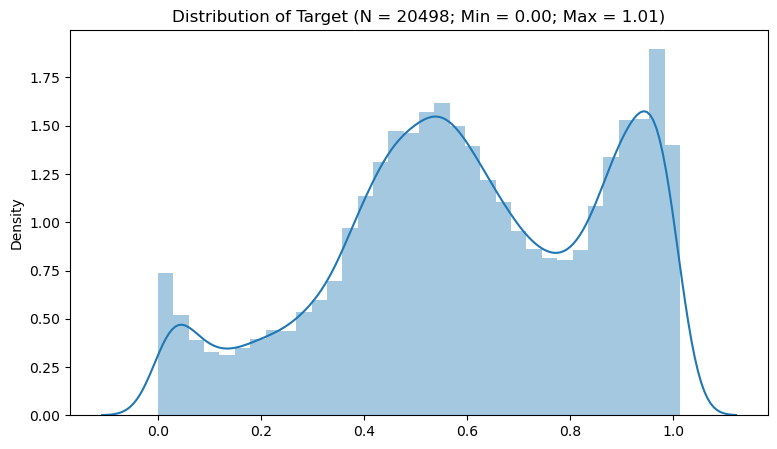

In [22]:
# plot target
plot_target(ser_target=df['target'])

### Write to s3

In [23]:
%%time

# to parquet
str_filename = 'df_raw.gzip'
str_uri = f's3://{str_project}/03_pricing_lgd/01_data_prep/01_data_collection/output/{str_filename}'
df.to_parquet(
    path=str_uri,
    compression='gzip',
)

CPU times: user 6.44 s, sys: 11.1 ms, total: 6.45 s
Wall time: 6.73 s
